## Задание

Создайте автокодировщик, удаляющий черные квадраты в случайных областях изображений.

Алгоритм действий:
1. Возьмите базу картинок Mnist.
2. На картинках в случайных местах сделайте чёрные квадраты размера 8 на 8.
3. Создайте и обучите автокодировщик восстанавливать оригинальные изображения из "зашумленных" квадратом изображений.
4. Добейтесь MSE < 0.0070 на тестовой выборке

## Импорт библиотек

In [1]:
# Отображение
import matplotlib.pyplot as plt

# Для работы с тензорами
import numpy as np

# Класс создания модели
from tensorflow.keras.models import Model

# Для загрузки данных
from tensorflow.keras.datasets import mnist

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization, Cropping2D

# Оптимизатор
from tensorflow.keras.optimizers import Adam

## Загрузка данных

In [2]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Нормировка данных

In [3]:
# Нормировка данных
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [9]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (60000, 28, 28, 1)
X_test: (10000, 28, 28, 1)


## Добавление черных квадратов

X_train_noisy: (60000, 28, 28, 1)
X_test_noisy: (10000, 28, 28, 1)


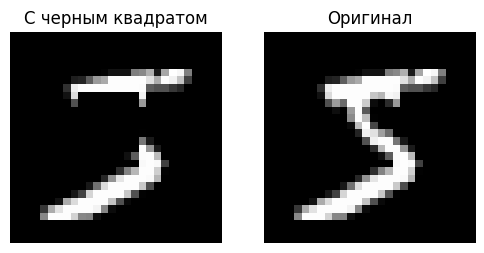

In [11]:
def add_black_squares(images, square_size=8):
    images_noisy = images.copy()
    for i in range(len(images)):
        x = np.random.randint(0, 28 - square_size)
        y = np.random.randint(0, 28 - square_size)
        images_noisy[i, x:x+square_size, y:y+square_size, 0] = 0
    return images_noisy

X_train_noisy = add_black_squares(X_train)
X_test_noisy = add_black_squares(X_test)

print(f"X_train_noisy: {X_train_noisy.shape}")
print(f"X_test_noisy: {X_test_noisy.shape}")

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(X_train_noisy[0].squeeze(), cmap='gray')
plt.title('С черным квадратом')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(X_train[0].squeeze(), cmap='gray')
plt.title('Оригинал')
plt.axis('off')
plt.show()

## Создание модели

In [12]:
inp = Input(shape=(28, 28, 1))

# Энкодер
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

# Декодер
x = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2DTranspose(1, (3, 3), strides=(2, 2), activation='sigmoid', padding='same')(x)

x = Cropping2D(cropping=((2, 2), (2, 2)))(x)

autoencoder = Model(inp, x)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 8, 8, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,497 (728.50 KB)

 Trainable params: 185,857 (726.00 KB)

 Non-trainable params: 640 (2.50 KB)

## Обучение модели

In [13]:
history = autoencoder.fit(
    X_train_noisy, X_train,
    validation_data=(X_test_noisy, X_test),
    epochs=30,
    batch_size=128,
    verbose=1
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0251 - val_loss: 0.0235
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0093 - val_loss: 0.0087
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0078 - val_loss: 0.0076
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0071 - val_loss: 0.0074
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0066 - val_loss: 0.0069
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0063 - val_loss: 0.0065
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0060 - val_loss: 0.0065
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0058 - val_loss: 0.0070
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0056 - val_loss: 0.0060
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0055 - val_loss: 0.0060
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0054 - val_loss: 0.0063
Epoch 12/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/st

## Вывод MSE

In [14]:
mse = autoencoder.evaluate(X_test_noisy, X_test, verbose=0)
print(f"MSE: {mse:.6f}")

MSE: 0.005652


## Визуализация работы автокодировщика

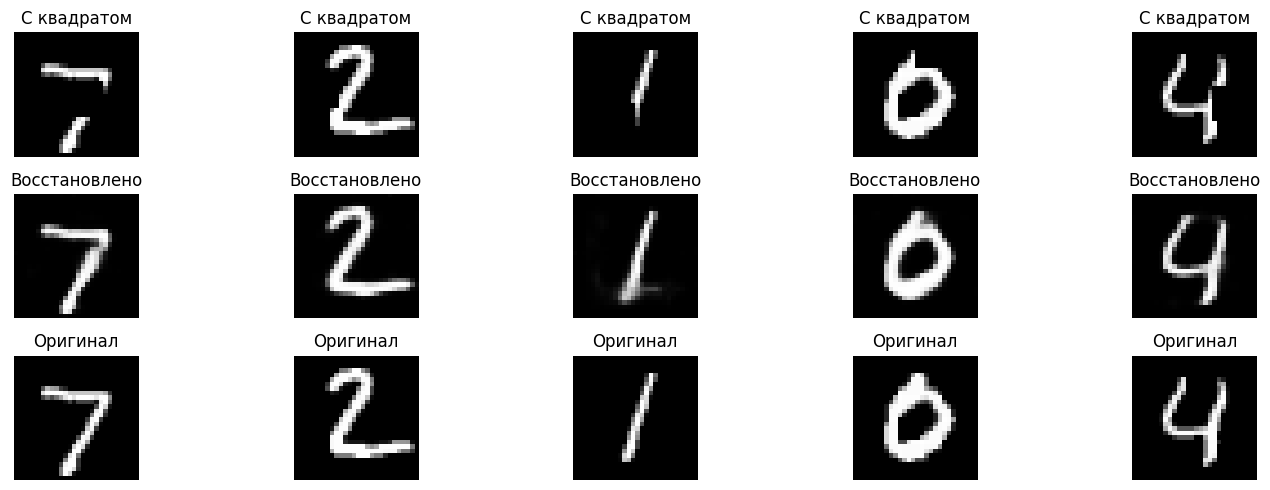

In [16]:
n = 5
preds = autoencoder.predict(X_test_noisy[:n], verbose=0)

plt.figure(figsize=(15, 5))
for i in range(n):
    plt.subplot(3, n, i+1)
    plt.imshow(X_test_noisy[i].squeeze(), cmap='gray')
    plt.title('С квадратом')
    plt.axis('off')

    plt.subplot(3, n, n+i+1)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title('Восстановлено')
    plt.axis('off')

    plt.subplot(3, n, 2*n+i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title('Оригинал')
    plt.axis('off')

plt.tight_layout()
plt.show()